Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 1024, 1)]            0         []                            
                                                                                                  
 conv1d_18 (Conv1D)          (None, 1024, 32)             128       ['input_4[0][0]']             
                                                                                                  
 max_pooling1d_6 (MaxPoolin  (None, 512, 32)              0         ['conv1d_18[0][0]']           
 g1D)                                                                                             
                                                                                                  
 conv1d_19 (Conv1D)          (None, 512, 64)              6208      ['max_pooling1d_6[0][0]'

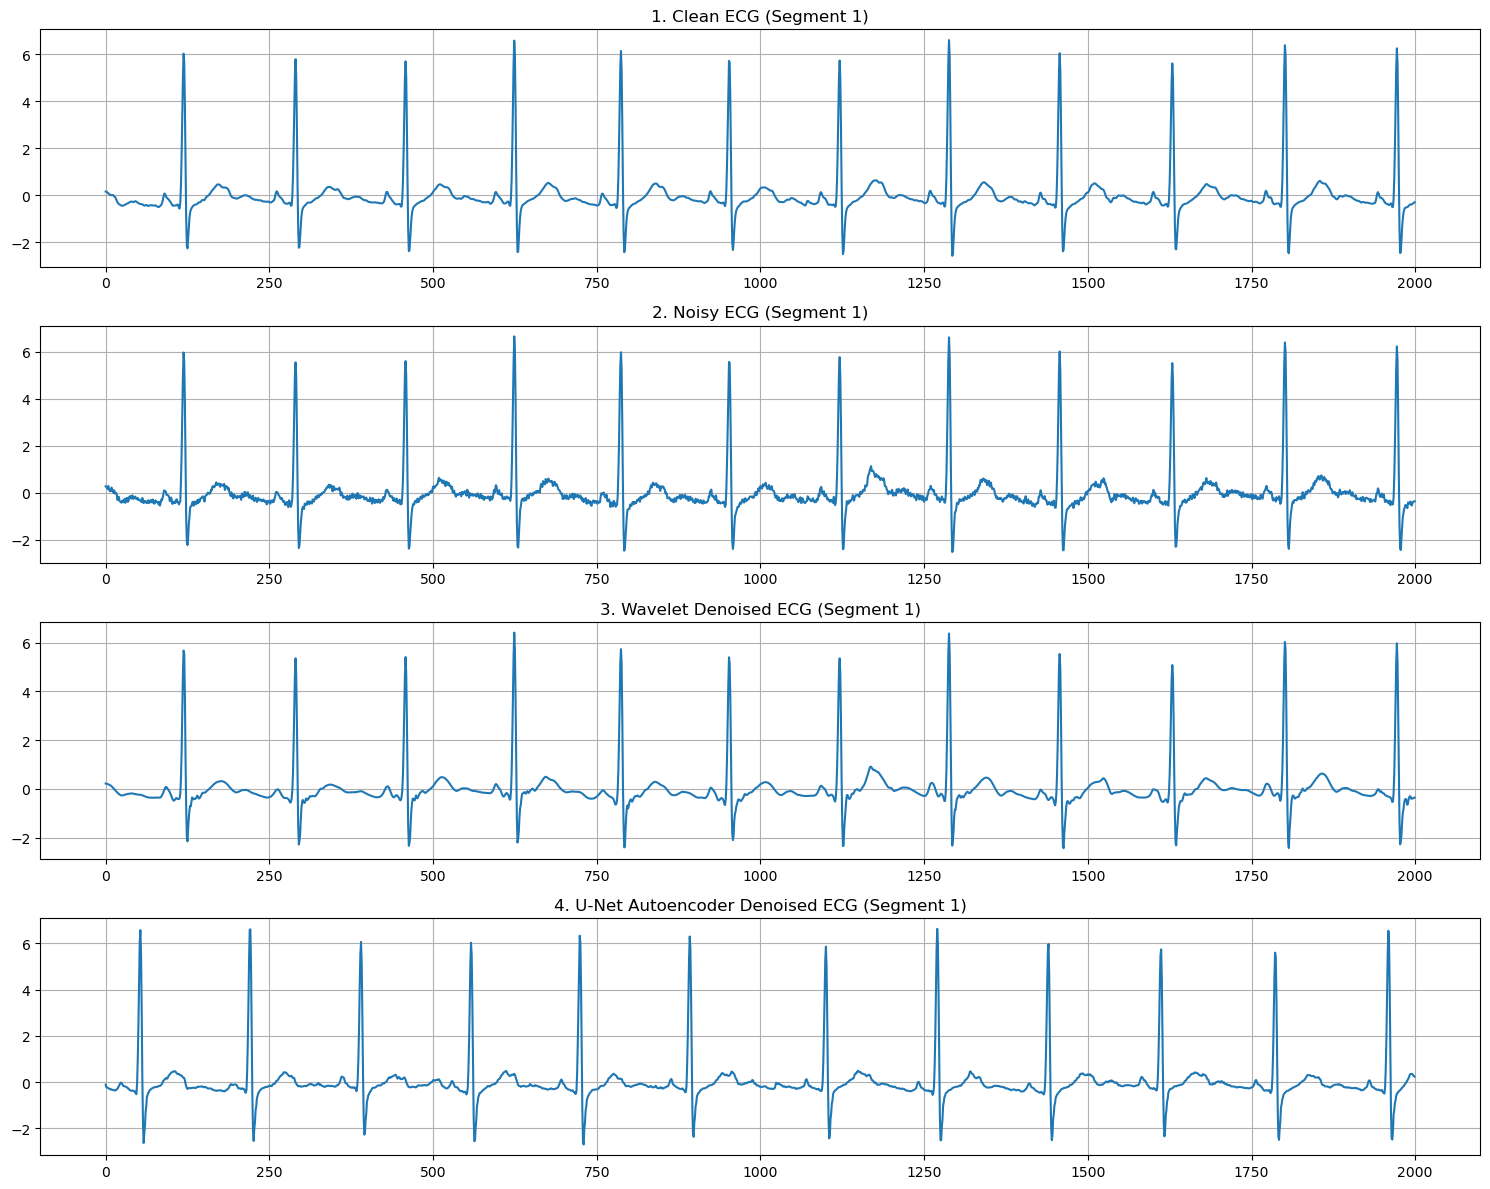

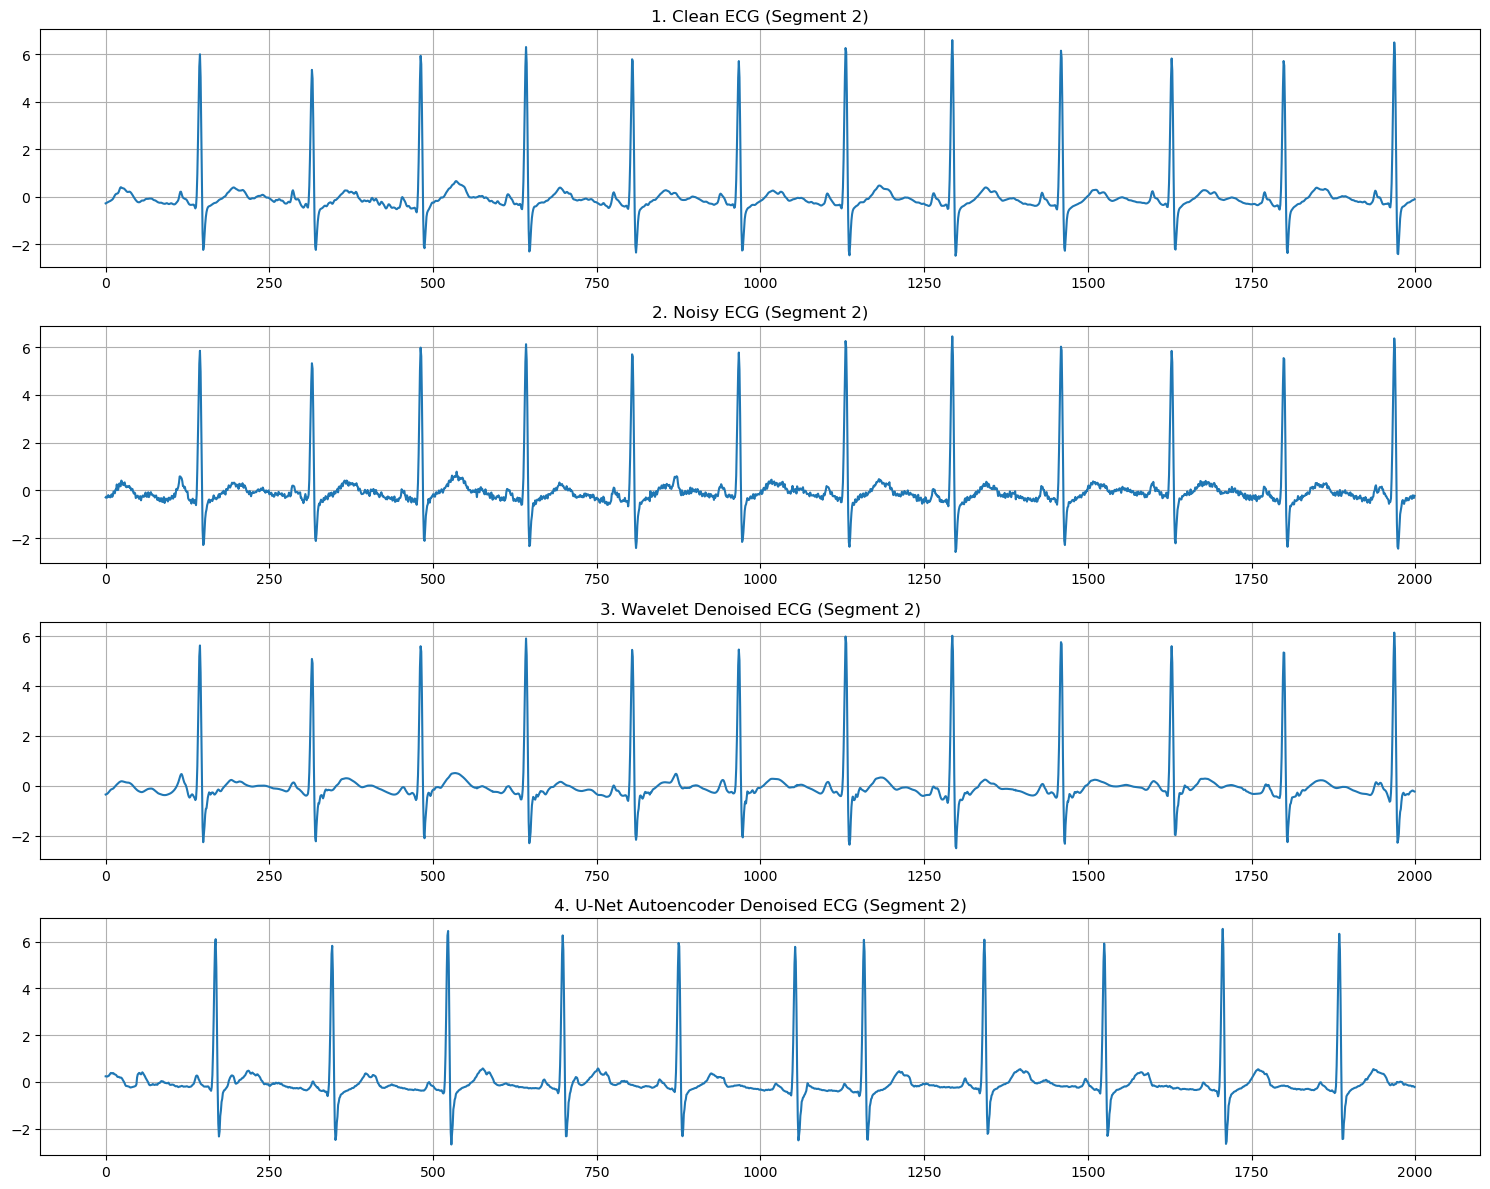

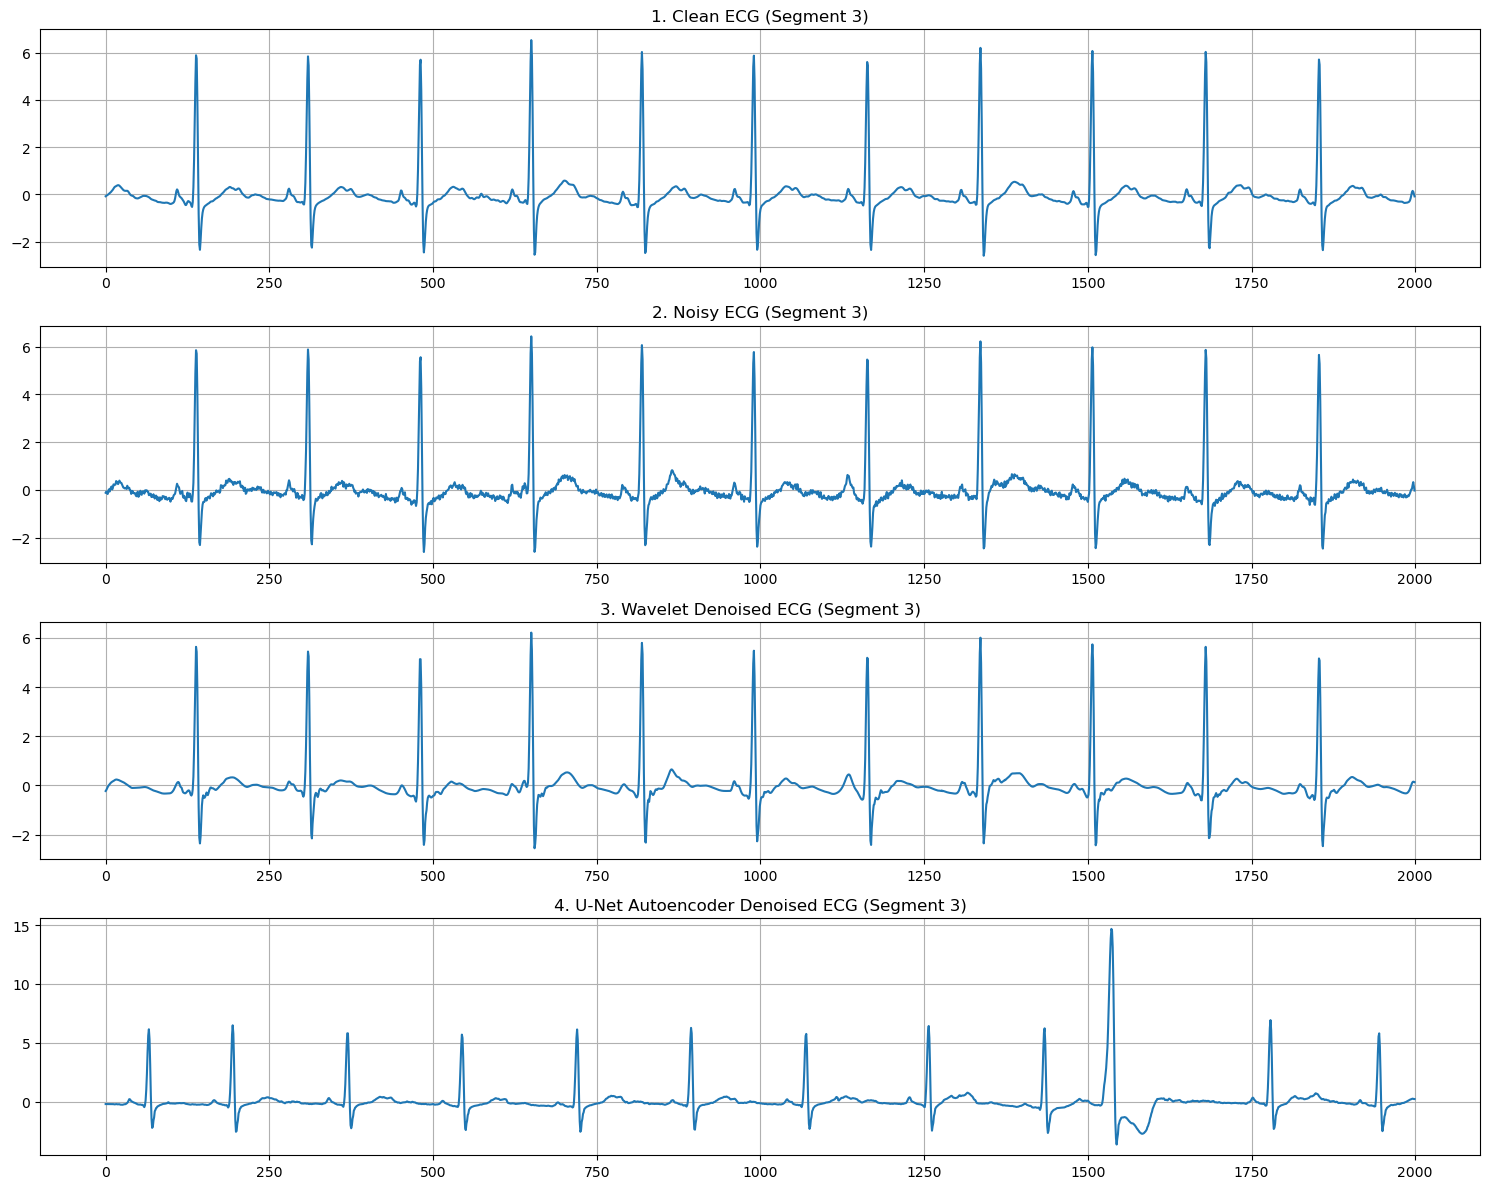

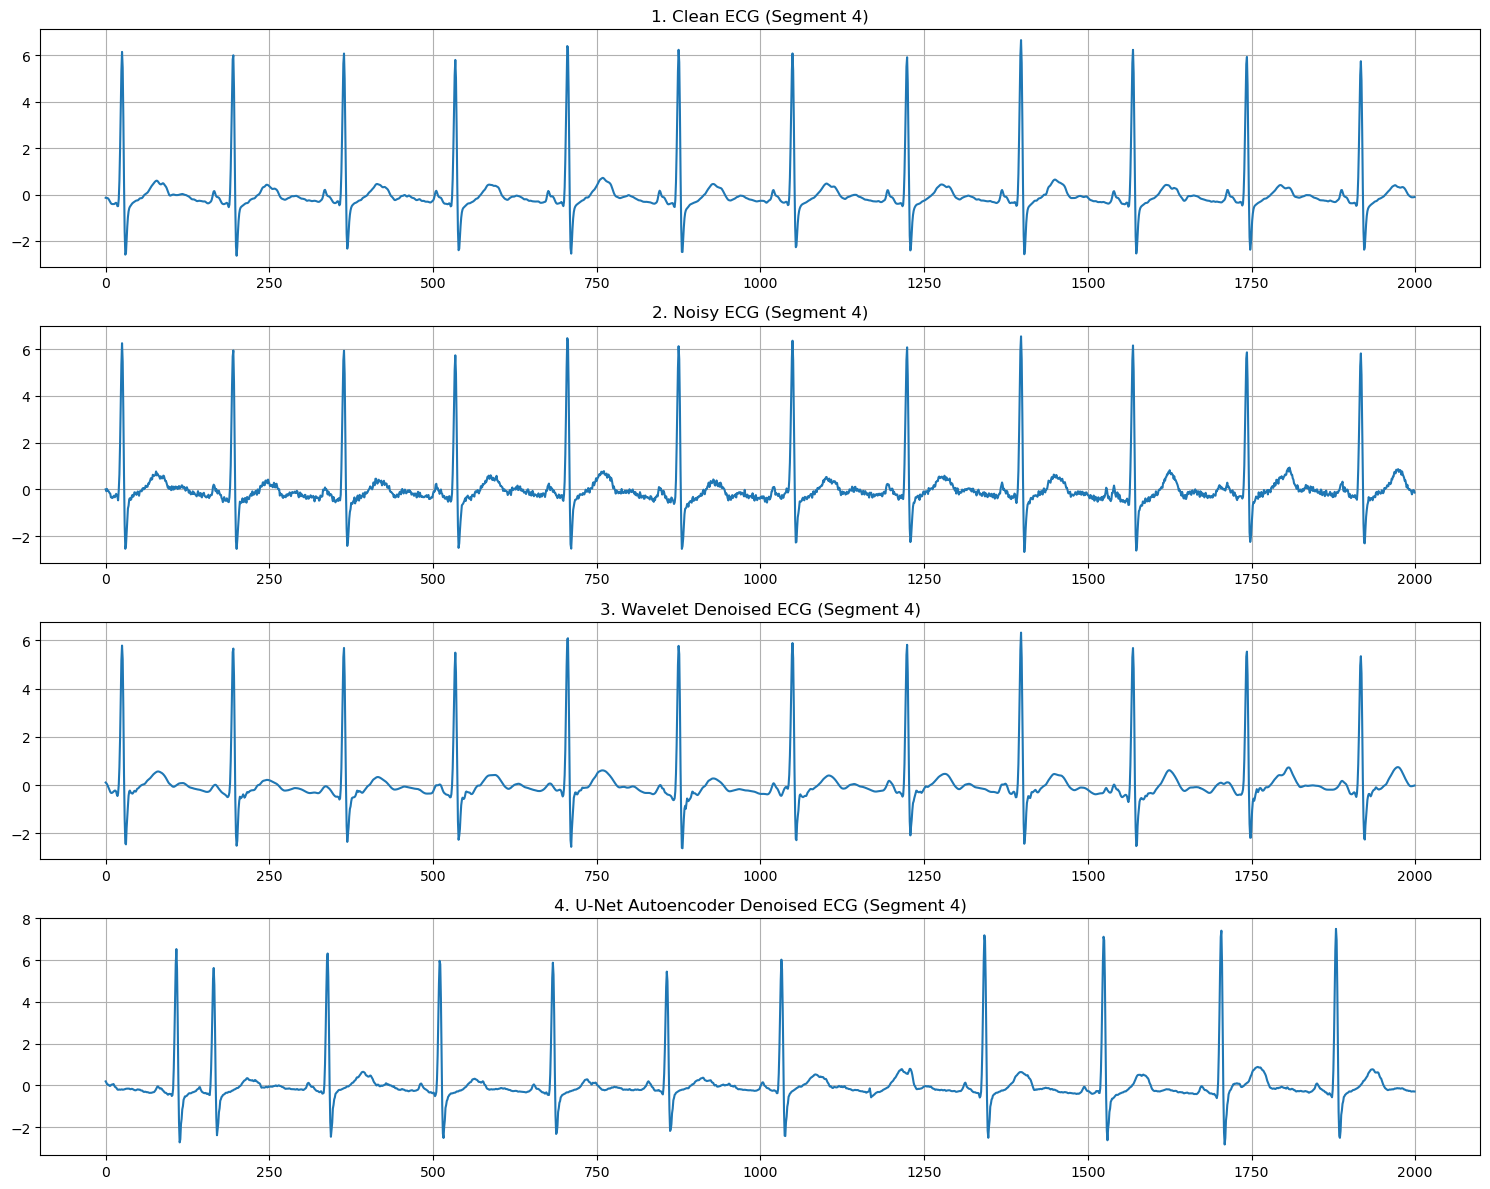

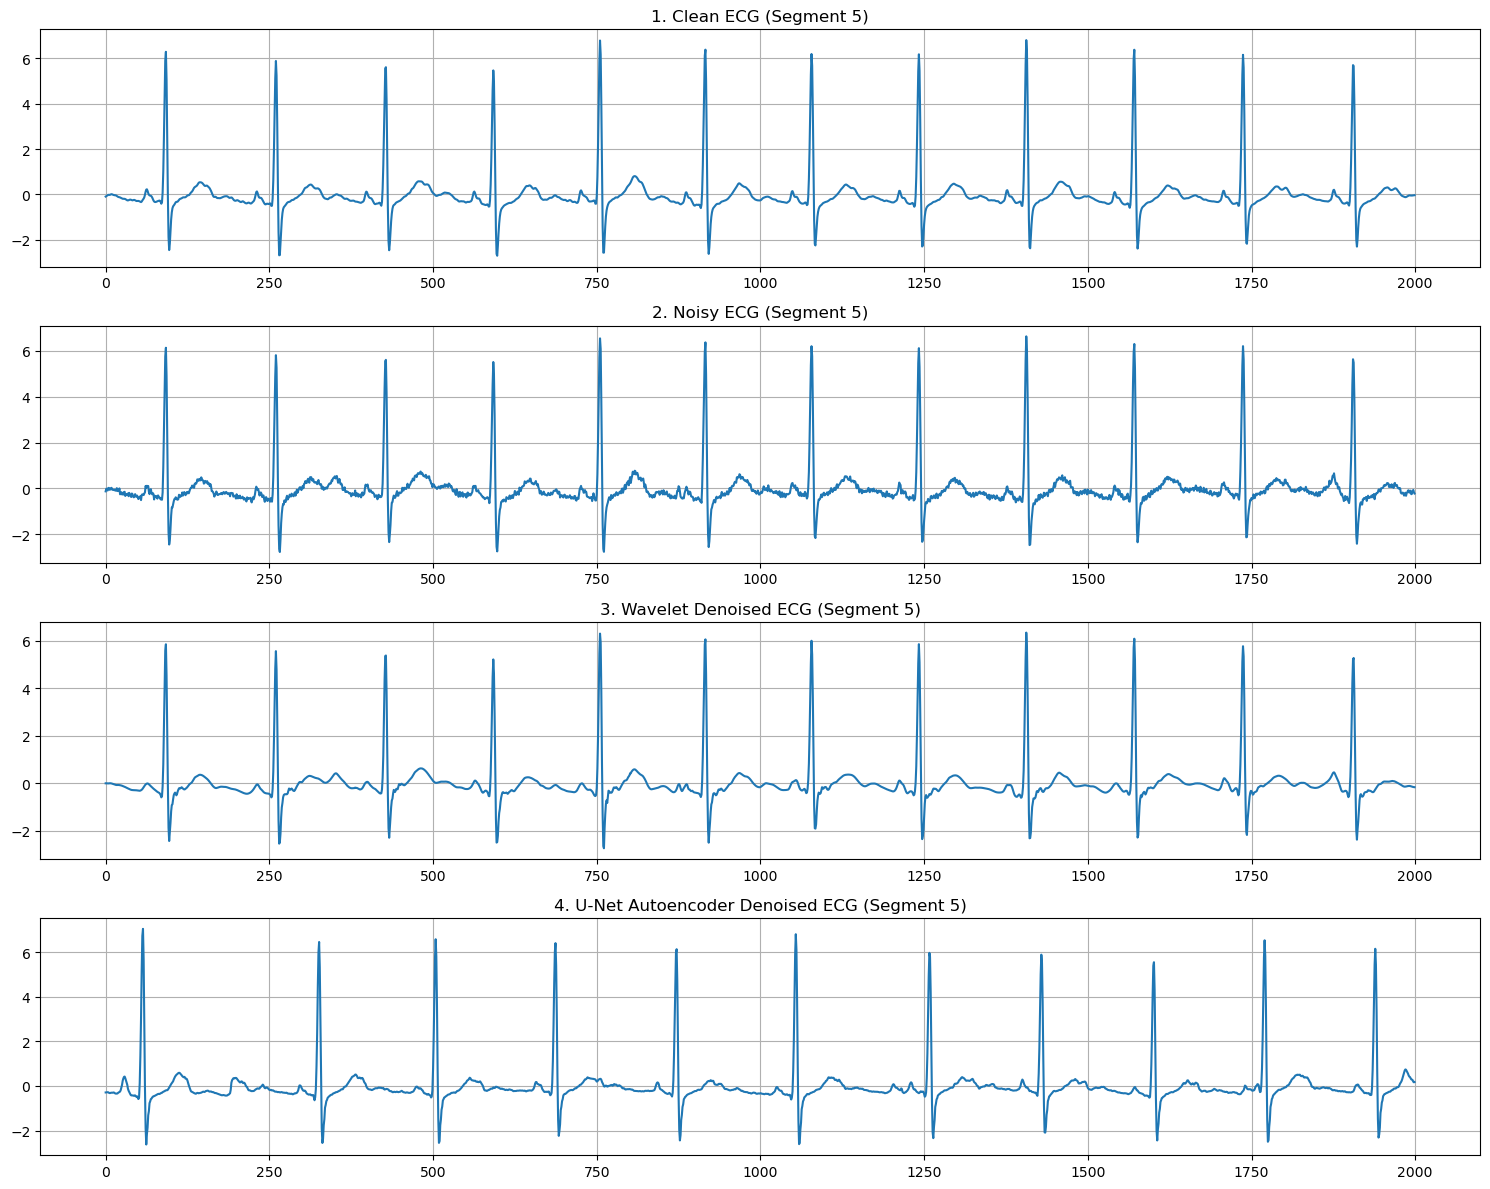

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from scipy.signal import butter, filtfilt 
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def normalize(signal):
    """Normalize signal to zero mean and unit variance."""
    mean = np.mean(signal)
    std = np.std(signal)
    if std < 1e-8:
        # logger.warning("Signal has near-zero variance; returning zeros")
        print("Signal has near-zero variance; returning zeros")
        return np.zeros_like(signal)
    return (signal - mean) / std

def bandpass_filter(signal, low=0.5, high=40, fs=200, order=2):
    b, a = butter(order, [low, high], btype='bandpass', fs=fs)
    return filtfilt(b, a, signal)

# === Load ECG data ===
clean_ecg = np.load("clean_ecg_for_test/1001_8.npy")
noisy_ecg = np.load("noisy_ecg_for_test/1001_8_noised.npy")


min_len = min(len(clean_ecg), len(noisy_ecg))
clean_ecg = clean_ecg[:min_len]
noisy_ecg = noisy_ecg[:min_len]

# Filter
clean_ecg = bandpass_filter(clean_ecg)

# Normalize
clean_ecg = normalize(clean_ecg)
noisy_ecg = normalize(noisy_ecg)

# === Prepare segments ===
segment_len = 1024
stride = segment_len
X, Y = [], []

for i in range(0, len(noisy_ecg) - segment_len + 1, stride):
    X.append(noisy_ecg[i:i+segment_len])
    Y.append(clean_ecg[i:i+segment_len])
X = np.array(X)[..., np.newaxis]  # shape: (n, 1024, 1)
Y = np.array(Y)[..., np.newaxis]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# === Define 1D U-Net model ===
def build_unet_1d(input_shape):
    inputs = Input(shape=input_shape)

    # Encoder
    c1 = Conv1D(32, 3, activation='relu', padding='same')(inputs)
    p1 = MaxPooling1D(2)(c1)

    c2 = Conv1D(64, 3, activation='relu', padding='same')(p1)
    p2 = MaxPooling1D(2)(c2)

    c3 = Conv1D(128, 3, activation='relu', padding='same')(p2)

    # Decoder
    u1 = UpSampling1D(2)(c3)
    concat1 = concatenate([u1, c2])
    c4 = Conv1D(64, 3, activation='relu', padding='same')(concat1)

    u2 = UpSampling1D(2)(c4)
    concat2 = concatenate([u2, c1])
    c5 = Conv1D(32, 3, activation='relu', padding='same')(concat2)

    outputs = Conv1D(1, 1, activation='linear', padding='same')(c5)

    model = Model(inputs, outputs)
    return model

model = build_unet_1d((segment_len, 1))
model.compile(optimizer=Adam(1e-3), loss='mse')
model.summary()

# === Train model ===
model.fit(X_train, Y_train, epochs=20, batch_size=32, validation_split=0.1)

# === Predict on test ===
Y_pred = model.predict(X_test)
autoencoder_output = Y_pred.squeeze().flatten()

# === Wavelet Denoising ===
def wavelet_denoise(signal, wavelet='db6', level=4, threshold_factor=0.5):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = threshold_factor * sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs = [pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs]
    return pywt.waverec(coeffs, wavelet)

wavelet_output = wavelet_denoise(noisy_ecg)
wavelet_output = wavelet_output[:len(clean_ecg)]

# === Plot ===
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

def plot_ecg_segments(clean_ecg, noisy_ecg, wavelet_output, autoencoder_output, fs=200, segment_length_secs=10, max_plots=5):
    segment_length = segment_length_secs * fs
    num_segments = min(len(clean_ecg) // segment_length, max_plots)

    for i in range(num_segments):
        start = i * segment_length
        end = start + segment_length

        plt.figure(figsize=(15, 12))

        plt.subplot(4, 1, 1)
        plt.plot(clean_ecg[start:end])
        plt.title(f"1. Clean ECG (Segment {i+1})")
        plt.grid()

        plt.subplot(4, 1, 2)
        plt.plot(noisy_ecg[start:end])
        plt.title(f"2. Noisy ECG (Segment {i+1})")
        plt.grid()

        plt.subplot(4, 1, 3)
        plt.plot(wavelet_output[start:end])
        plt.title(f"3. Wavelet Denoised ECG (Segment {i+1})")
        plt.grid()

        plt.subplot(4, 1, 4)
        plt.plot(autoencoder_output[start:end])
        plt.title(f"4. U-Net Autoencoder Denoised ECG (Segment {i+1})")
        plt.grid()

        plt.tight_layout()
        plt.show()

plot_ecg_segments(clean_ecg, noisy_ecg, wavelet_output, autoencoder_output, fs=200, segment_length_secs=10, max_plots=5)
        